### Sales based on advertising expenditure

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
df=pd.read_csv('advertising.csv')

In [3]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [4]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [5]:
df.shape

(200, 4)

In [6]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')

In [10]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [12]:
x=df[['TV', 'Radio', 'Newspaper']]
y=df[['Sales']]

In [14]:
lr=LinearRegression()

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=23,test_size=0.20)
model=lr.fit(x_train,y_train)
tahmin=lr.predict(x_test)

In [18]:
r2_score(y_test, tahmin)

0.910204221189731

In [19]:
mean_squared_error(y_test,tahmin)**.5

1.6791157645635726

In [23]:
residuals = y_test-tahmin

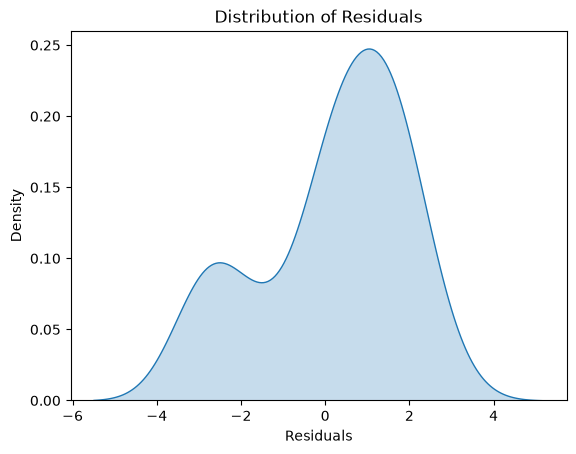

In [26]:
sns.kdeplot(x=residuals['Sales'], fill=True)
plt.xlabel('Residuals')
plt.title('Distribution of Residuals')
plt.show()

In [27]:
coefficients = pd.DataFrame({
    'Channel': x_train.columns,
    'Coefficient': model.coef_.ravel()
})

print(coefficients)
print('Intercept:', model.intercept_)

     Channel  Coefficient
0         TV     0.046485
1      Radio     0.181416
2  Newspaper     0.000079
Intercept: [2.92813281]


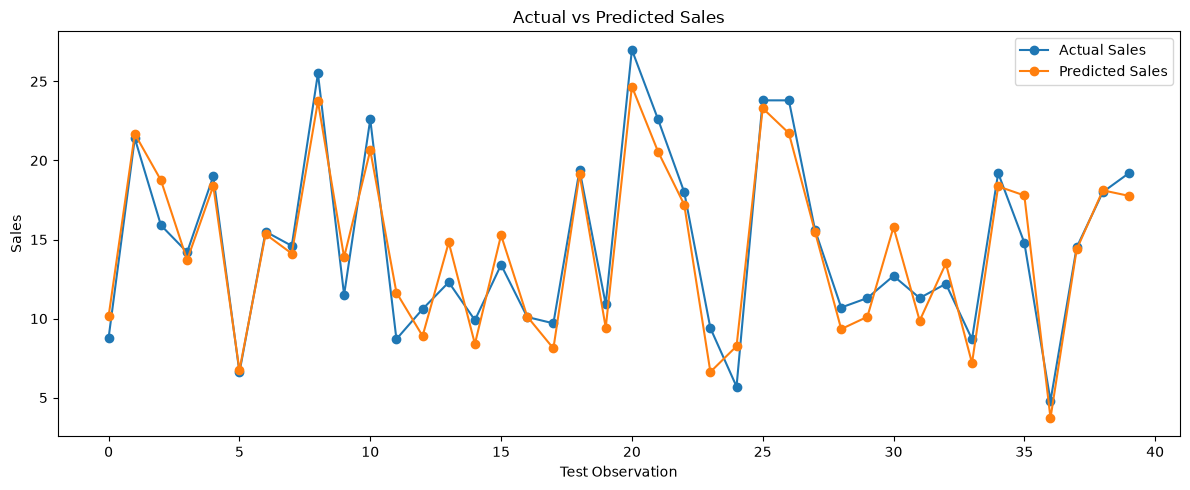

In [30]:
actual = np.asarray(y_test).ravel()
predicted = np.asarray(tahmin).ravel()

plt.figure(figsize=(12, 5))
plt.plot(actual, label='Actual Sales', marker='o')
plt.plot(predicted, label='Predicted Sales', marker='o')
plt.xlabel('Test Observation')
plt.ylabel('Sales')
plt.title('Actual vs Predicted Sales')
plt.legend()
plt.tight_layout()
plt.show()